In [19]:
import os
import pandas as pd
import pyodbc
import warnings
import matplotlib.pyplot as plt
import calendar

warnings.filterwarnings('ignore')

# Pegando usuário e caminho base para senhas
usuario = os.getenv('USERNAME')
path_senhas = fr'C:\Users\{usuario}\OneDrive - CAIXA Consórcio\Documentos\SENHA_BANCO_DADOS'

# Carregar credenciais
df_senhas = pd.read_excel(fr'{path_senhas}\SENHAS.xlsx')
server, database, username, password = df_senhas.iloc[0, 0:4]

# Conexão com o SQL Server
conn = pyodbc.connect(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password}'
)

In [20]:
# --- BASE 1: consulta SQL ---
query_base1 = """
SELECT 
    FT.AnoMesRef,
    FT.ID_Cota,
    FT.Tipo_Pessoa,
    DP.CD_InscricaoNacional,
    VA.DT_EntregaBem
FROM 
    FT0015_CarteiraCotas AS FT
LEFT JOIN 
    DM0013_Pessoas AS DP ON FT.ID_Pessoa = DP.ID_Pessoa
LEFT JOIN 
    FT0002_VendaAlocacoes AS VA ON FT.ID_Cota = VA.ID_Cota
LEFT JOIN 
    FT0018_Contemplacao AS VB ON FT.ID_Cota = VB.ID_Cota
WHERE
    FT.AnoMesRef >= '202405' AND FT.ST_Contrato = 'Ativo'
"""

print("📥 Executando consulta Base 1...")
df_base1 = pd.read_sql(query_base1, conn)

# --- BASE 2: buscar dados de score e rating ---
query_base2 = """
SELECT
    a.ID_Cota,
    a.DT_Alocacao,
    a.Tipo_Pessoa,
    b.CD_InscricaoNacional AS CPF_CNPJ
FROM [dbo].[FT0002_VendaAlocacoes] a
LEFT JOIN [dbo].[DM0013_Pessoas] b ON a.ID_Pessoa = b.ID_Pessoa
"""

print("📥 Executando consulta Base 2 - alocação e pessoas...")
df_base2 = pd.read_sql(query_base2, conn)

# Função para tratar documento (remover parte decimal)
def tratando_documento(val):
    val = float(val)
    val = str(val).split('.')[0]
    return val

def safra_alocacao(val):
    val = str(val)[0:7]
    return(val)

df_base2['CPF_CNPJ'] = df_base2['CPF_CNPJ'].apply(tratando_documento)
df_base2['DT_Alocacao'] = pd.to_datetime(df_base2['DT_Alocacao'], format='%Y-%m-%d')
#df_base2['Safra_Alocacao'] = df_base2['DT_Alocacao'].apply(safra_alocacao)

# Carregar base de score de crédito (arquivo CSV externo)
path_score = fr'C:\Users\{usuario}\CAIXA Consórcio\Risco de Crédito e Antifraude - Documentos\MODELOS\MODELAGEM\SCORE_CREDITO_BOA_VISTA\BASES_HISTORICAS'
df_score = pd.read_csv(fr'{path_score}\score_credito_full.csv', delimiter=";")
df_score = df_score[df_score['Score_Credito'] > 2]
df_score['CPF_CNPJ'] = df_score['CPF_CNPJ'].apply(tratando_documento)
df_score['Data'] = pd.to_datetime(df_score['Data'], format='%Y-%m-%d')
#df_score['Safra_Alocacao'] = df_score['Data'].apply(safra_alocacao)

# Fazer merge entre base2 e score pelo CPF/CNPJ
df_base2 = df_base2.merge(df_score, how='left', on='CPF_CNPJ')

# Calcular diferença de datas para pegar a mais próxima
df_base2['Diferenca_Datas'] = abs(df_base2['DT_Alocacao'] - df_base2['Data']).dt.days

# Manipulando para pegar a menos diferença de datas
df_base2 = df_base2.sort_values(by=['Diferenca_Datas'], ascending=True)
df_base2 = df_base2.drop_duplicates(subset=['ID_Cota'], keep='first')

# Filtrar para diferença máxima 30 dias
df_base2 = df_base2[df_base2['Diferenca_Datas'] <= 30]

# Base para join
df_base3 = df_base2[['ID_Cota', 'Score_Credito']]

# Unindo com a base main
df_base1 = df_base1.merge(df_base3, how='left', on=['ID_Cota'])

# Construindo base final
df_main = df_base1[['AnoMesRef', 'Tipo_Pessoa', 'CD_InscricaoNacional', 'Score_Credito']].groupby(by=['AnoMesRef', 'Tipo_Pessoa', 'CD_InscricaoNacional']).mean().reset_index(level=['AnoMesRef', 'Tipo_Pessoa', 'CD_InscricaoNacional'])

# Funções para rating
def faixas_score_pf():
    intervalos = [0, 337, 416, 476, 524, 567, 607, 651, 701, 1000]
    lista_rating = ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', 'AA']
    return intervalos, lista_rating

def faixas_score_pj():
    intervalos = [0, 187, 281, 359, 426, 495, 562, 631, 706, 1000]
    lista_rating = ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', 'AA']
    return intervalos, lista_rating

def define_rating(score, intervalos, lista_rating):
    for i in range(len(intervalos) - 1):
        if intervalos[i] < score <= intervalos[i + 1]:
            return lista_rating[i]
    return None

# Aplicar rating
intervalos_pf, lista_rating_pf = faixas_score_pf()
intervalos_pj, lista_rating_pj = faixas_score_pj()

def atribui_rating(row):
    if pd.isna(row['Score_Credito']):
        return None
    if row['Tipo_Pessoa'] == 'F':
        return define_rating(row['Score_Credito'], intervalos_pf, lista_rating_pf)
    else:
        return define_rating(row['Score_Credito'], intervalos_pj, lista_rating_pj)

df_main['Rating'] = df_main.apply(atribui_rating, axis=1)

# Retirando Ratins em branco
df_main = df_main[df_main['Rating'].notna()]

📥 Executando consulta Base 1...
📥 Executando consulta Base 2 - alocação e pessoas...


In [21]:
df_main.head()

,AnoMesRef,Tipo_Pessoa,CD_InscricaoNacional,Score_Credito,Rating
0,202405,F,00000687995,369.0,G
1,202405,F,00000699144,702.0,AA
2,202405,F,00000917583,581.0,C
3,202405,F,00001123726,468.0,F
4,202405,F,00001502158,722.0,AA


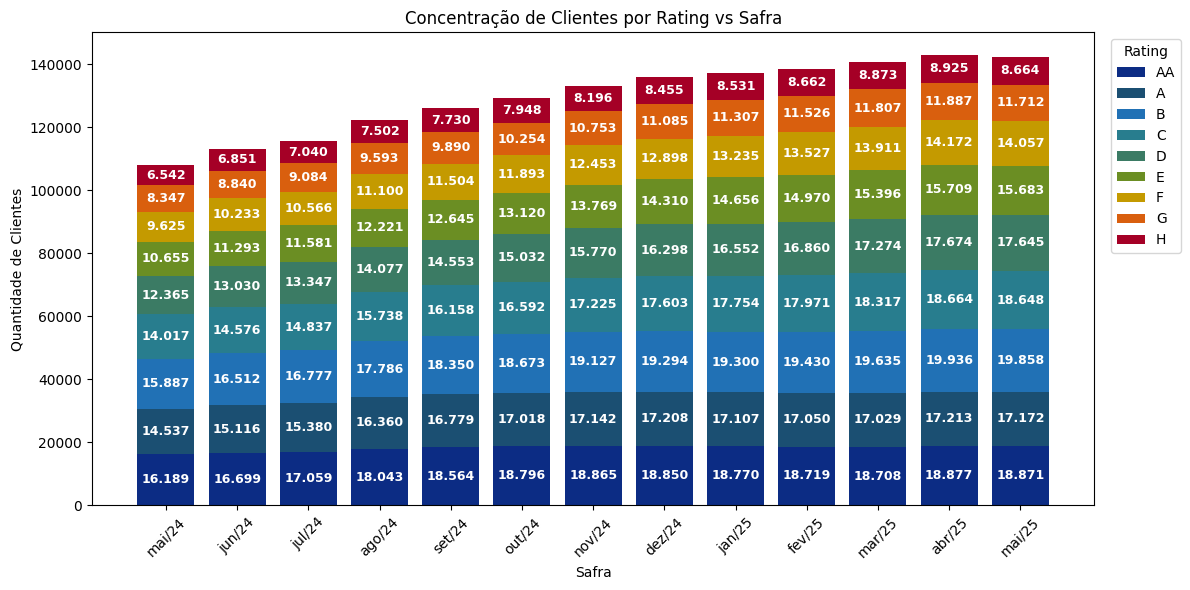

In [22]:
# === 2. DEFINIÇÃO DA ORDEM E CORES ===
ordem_rating = ['AA', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
cores = {
    'AA': '#0c2c84',
    'A':  '#1b4f72',
    'B':  '#2171b5',
    'C':  '#287d8e',
    'D':  '#3b7b64',
    'E':  '#6b8e23',
    'F':  '#c49a00',
    'G':  '#d95f0e',
    'H':  '#a50026'
}

# === 3. AGRUPAMENTO E PIVÔ ===
df_agrupado = (
    df_main.groupby(['AnoMesRef', 'Rating'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordem_rating, fill_value=0)
    .sort_index()
)

# Função para formatar AnoMesRef no formato 'Jan/24'
def format_ano_mes(ano_mes):
    ano_mes_str = str(ano_mes)
    ano = ano_mes_str[:4]
    mes = int(ano_mes_str[4:6])
    mes_abrev = calendar.month_abbr[mes]
    ano_abrev = ano[2:]
    return f"{mes_abrev}/{ano_abrev}"

# Aplica a formatação ao índice
df_agrupado.index = df_agrupado.index.map(format_ano_mes)
x_labels = df_agrupado.index

# === 4. PLOT COM FORMATAÇÃO ===
fig, ax = plt.subplots(figsize=(12, 6))
bottom = [0] * len(df_agrupado)

for rating in ordem_rating:
    valores = df_agrupado[rating]
    bars = ax.bar(x_labels, valores, bottom=bottom, color=cores[rating], label=rating)

    for i, (bar, valor) in enumerate(zip(bars, valores)):
        if valor > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + valor / 2,
                f"{int(valor):,}".replace(",", "."),
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    bottom = [b + v for b, v in zip(bottom, valores)]

# === 5. AJUSTES FINAIS ===
ax.set_title("Concentração de Clientes por Rating vs Safra")
ax.set_xlabel("Safra")
ax.set_ylabel("Quantidade de Clientes")
ax.legend(title="Rating", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

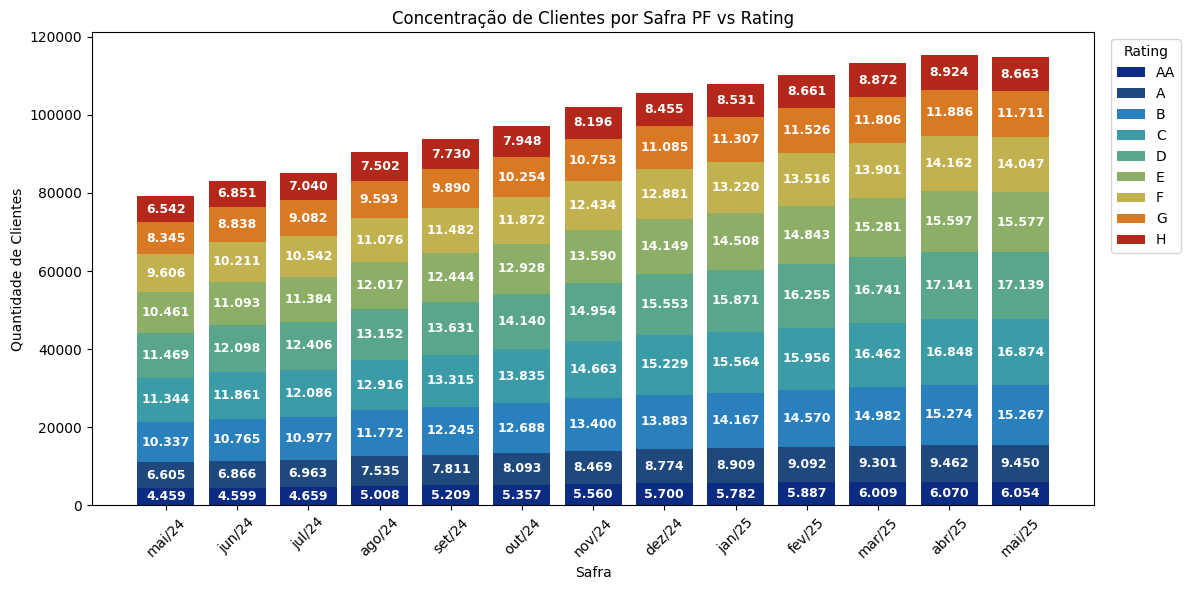

In [29]:
# === 2. DEFINIÇÃO DA ORDEM E CORES (cores menos claras) ===
ordem_rating = ['AA', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
cores = {
    'AA': '#0c2c84',  # azul escuro
    'A':  '#1f497d',  # azul médio escuro
    'B':  '#2a7fbd',  # azul médio
    'C':  '#3b9ca8',  # verde-azulado médio
    'D':  '#59a68a',  # verde médio
    'E':  '#8cae67',  # verde oliva médio
    'F':  '#c2b24f',  # amarelo mostarda escuro
    'G':  '#d97924',  # laranja escuro
    'H':  '#b3281a'   # vermelho escuro
}

# === 3. AGRUPAMENTO E PIVÔ ===
df_agrupado = (
    df_main[df_main['Tipo_Pessoa'] == 'F'].groupby(['AnoMesRef', 'Rating'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordem_rating, fill_value=0)
    .sort_index()
)

# Função para formatar AnoMesRef no formato 'Jan/24'
def format_ano_mes(ano_mes):
    ano_mes_str = str(ano_mes)
    ano = ano_mes_str[:4]
    mes = int(ano_mes_str[4:6])
    mes_abrev = calendar.month_abbr[mes]
    ano_abrev = ano[2:]
    return f"{mes_abrev}/{ano_abrev}"

# Aplica a formatação ao índice
df_agrupado.index = df_agrupado.index.map(format_ano_mes)
x_labels = df_agrupado.index

# === 4. PLOT COM FORMATAÇÃO ===
fig, ax = plt.subplots(figsize=(12, 6))
bottom = [0] * len(df_agrupado)

for rating in ordem_rating:
    valores = df_agrupado[rating]
    bars = ax.bar(x_labels, valores, bottom=bottom, color=cores[rating], label=rating)

    for i, (bar, valor) in enumerate(zip(bars, valores)):
        if valor > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + valor / 2,
                f"{int(valor):,}".replace(",", "."),
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    bottom = [b + v for b, v in zip(bottom, valores)]

# === 5. AJUSTES FINAIS ===
ax.set_title("Concentração de Clientes por Safra PF vs Rating")
ax.set_xlabel("Safra")
ax.set_ylabel("Quantidade de Clientes")
ax.legend(title="Rating", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

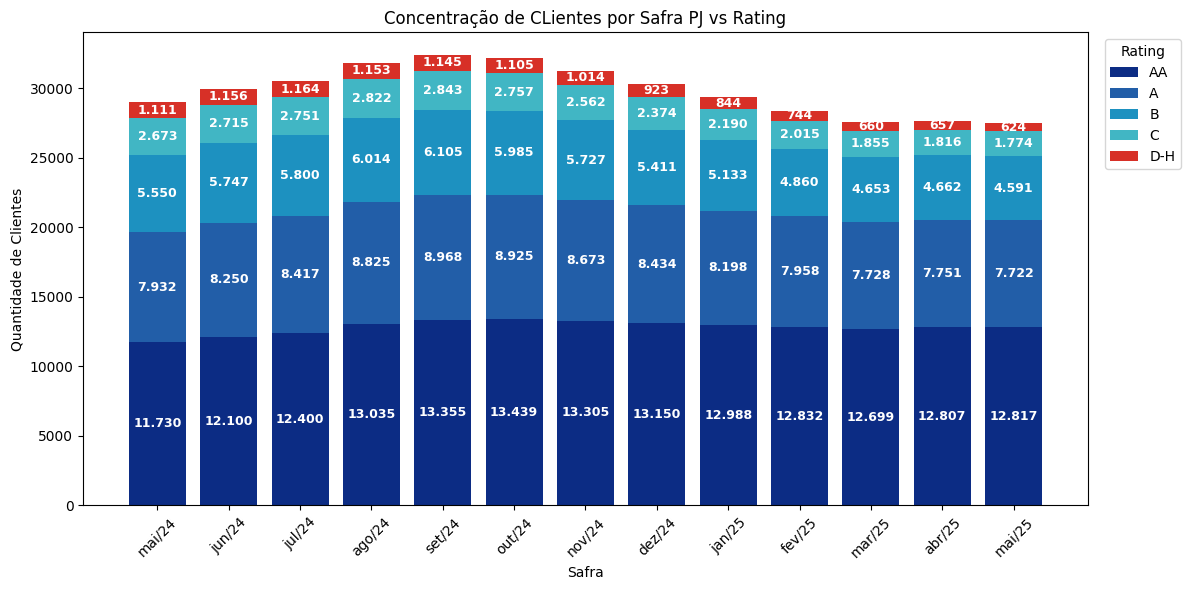

In [28]:
# === 2. DEFINIÇÃO DA ORDEM E CORES ===
ordem_rating = ['AA', 'A', 'B', 'C', 'D-H']
cores = {
    'AA': '#0c2c84',
    'A':  '#225ea8',
    'B':  '#1d91c0',
    'C':  '#41b6c4',
    'D-H': '#d73027',
}

# === 3. AGRUPAMENTO E PIVÔ ===
df_main_aux = df_main.replace({'D': 'D-H', 'E': 'D-H', 'F': 'D-H', 'G': 'D-H', 'H': 'D-H'})
df_agrupado = (
    df_main_aux[df_main_aux['Tipo_Pessoa'] == 'J'].groupby(['AnoMesRef', 'Rating'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordem_rating, fill_value=0)
    .sort_index()
)

# Função para formatar AnoMesRef no formato 'Jan/24'
def format_ano_mes(ano_mes):
    ano_mes_str = str(ano_mes)
    ano = ano_mes_str[:4]
    mes = int(ano_mes_str[4:6])
    mes_abrev = calendar.month_abbr[mes]
    ano_abrev = ano[2:]
    return f"{mes_abrev}/{ano_abrev}"

# Aplica a formatação ao índice
df_agrupado.index = df_agrupado.index.map(format_ano_mes)
x_labels = df_agrupado.index

# === 4. PLOT COM FORMATAÇÃO ===
fig, ax = plt.subplots(figsize=(12, 6))
bottom = [0] * len(df_agrupado)

for rating in ordem_rating:
    valores = df_agrupado[rating]
    bars = ax.bar(x_labels, valores, bottom=bottom, color=cores[rating], label=rating)

    for i, (bar, valor) in enumerate(zip(bars, valores)):
        if valor > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + valor / 2,
                f"{int(valor):,}".replace(",", "."),
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    bottom = [b + v for b, v in zip(bottom, valores)]

# === 5. AJUSTES FINAIS ===
ax.set_title("Concentração de CLientes por Safra PJ vs Rating")
ax.set_xlabel("Safra")
ax.set_ylabel("Quantidade de Clientes")
ax.legend(title="Rating", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
